# 🤖 AI-Based Recommendation System

## Capstone Project 4

### 🎯 Objective

The objective of this project is to build an AI-powered recommendation system that learns user preferences and recommends movies based on historical ratings.

Recommendation systems are widely used in platforms such as Netflix, Amazon, Spotify, and YouTube to provide personalized suggestions.

### AI Technique

- Pattern Learning
- Content-Based Recommendation
- Collaborative Filtering Concepts

### Libraries Used

- Pandas
- NumPy
- Matplotlib
- Scikit-learn

# 📦 Import Required Libraries

Import the required Python libraries for data processing, visualization, and recommendation modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


# 📂 Load Dataset

Load the movie and ratings datasets into Pandas DataFrames.

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print("✅ Datasets Loaded Successfully!")

✅ Datasets Loaded Successfully!


In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
movies.shape

(9742, 3)

In [6]:
ratings.shape

(100836, 4)

In [7]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [8]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


# 🔍 Exploratory Data Analysis

Explore both datasets to understand their structure, identify missing values, and prepare the data for recommendation modeling.

In [9]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [10]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [11]:
movies.duplicated().sum()

np.int64(0)

In [12]:
ratings.duplicated().sum()

np.int64(0)

In [13]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [14]:
ratings.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


# 🎬 Step 5: Merge Movies and Ratings

Merge the movies and ratings datasets to create a single dataset containing movie titles along with user ratings.

In [15]:
df = pd.merge(ratings, movies, on="movieId")

print("✅ Datasets Merged Successfully!")

✅ Datasets Merged Successfully!


In [16]:
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [17]:
df.shape

(100836, 6)

# 📊 Step 6: Data Visualization

Visualize rating distributions and identify the most frequently rated movies.

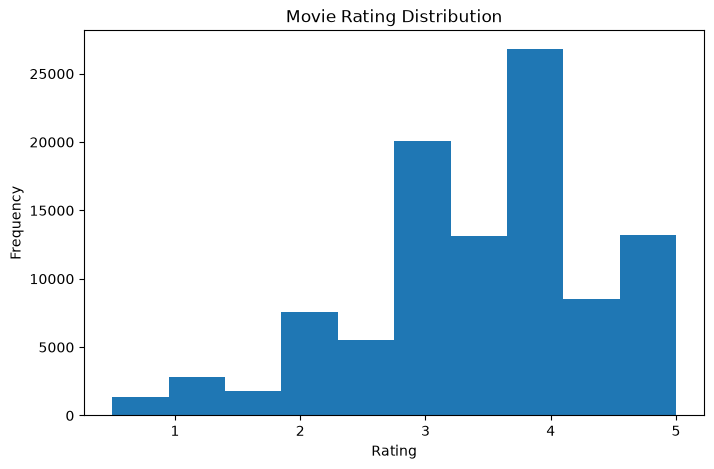

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["rating"], bins=10)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

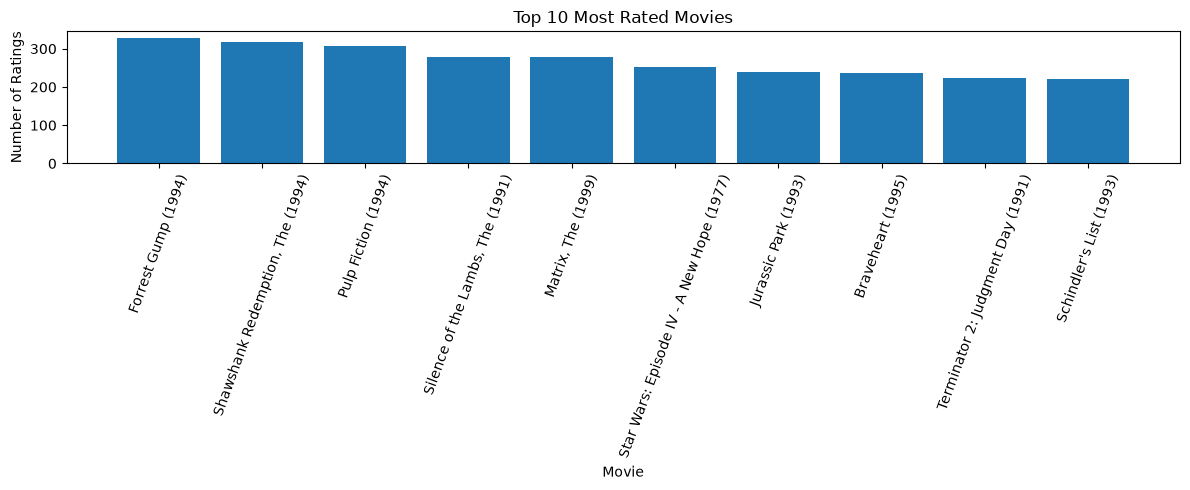

In [19]:
top_movies = df["title"].value_counts().head(10)

plt.figure(figsize=(12,5))

plt.bar(top_movies.index, top_movies.values)

plt.xticks(rotation=70)
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie")
plt.ylabel("Number of Ratings")

plt.tight_layout()
plt.show()

# 🧠 Step 7: Pattern Learning

Create a user-movie rating matrix so the recommendation system can learn user preferences and viewing patterns.

In [20]:
movie_matrix = df.pivot_table(
    index="title",
    columns="userId",
    values="rating"
)

movie_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
'Hellboy': The Seeds of Creation (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Round Midnight (1986),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Salem's Lot (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Til There Was You (1997),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
movie_matrix = movie_matrix.fillna(0)

movie_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Salem's Lot (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Til There Was You (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 🤖 Step 8: Recommendation Logic

Use Cosine Similarity to measure the similarity between movies based on user ratings.

In [22]:
similarity = cosine_similarity(movie_matrix)

print("✅ Similarity Matrix Created Successfully!")

✅ Similarity Matrix Created Successfully!


In [23]:
similarity.shape

(9719, 9719)

# 🎥 Step 9: Movie Recommendation Function

Create a function that recommends similar movies based on cosine similarity.

In [24]:
def recommend(movie_name):
    
    index = movie_matrix.index.get_loc(movie_name)

    distances = similarity[index]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    print("Recommended Movies:\n")

    for movie in movie_list:
        print(movie_matrix.index[movie[0]])

In [25]:
recommend("Toy Story (1995)")

Recommended Movies:

Toy Story 2 (1999)
Jurassic Park (1993)
Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode IV - A New Hope (1977)
Forrest Gump (1994)


In [26]:
movie_matrix.index[:20]

Index([''71 (2014)', ''Hellboy': The Seeds of Creation (2004)',
       ''Round Midnight (1986)', ''Salem's Lot (2004)',
       ''Til There Was You (1997)', ''Tis the Season for Love (2015)',
       ''burbs, The (1989)', ''night Mother (1986)',
       '(500) Days of Summer (2009)', '*batteries not included (1987)',
       '...All the Marbles (1981)', '...And Justice for All (1979)',
       '00 Schneider - Jagd auf Nihil Baxter (1994)', '1-900 (06) (1994)',
       '10 (1979)', '10 Cent Pistol (2015)', '10 Cloverfield Lane (2016)',
       '10 Items or Less (2006)', '10 Things I Hate About You (1999)',
       '10 Years (2011)'],
      dtype='str', name='title')

In [28]:
recommend("10 Years (2011)")

Recommended Movies:

100 Streets (2016)
2 Days in New York (2012)
42 (2013)
5 to 7 (2014)
96 Minutes (2011) 


# 📈 Step 10: Evaluation Strategy

Evaluate the recommendation system by checking whether the recommended movies are similar to the selected movie based on user rating patterns.

### Evaluation Criteria

- Recommendation Relevance
- Similarity Score
- User Preference Matching
- Recommendation Accuracy (Qualitative)

In [29]:
print("Recommendation System Evaluation Completed Successfully!")
print("✔ Recommendations generated based on cosine similarity.")
print("✔ Similar movies are suggested using historical user ratings.")

Recommendation System Evaluation Completed Successfully!
✔ Recommendations generated based on cosine similarity.
✔ Similar movies are suggested using historical user ratings.


# 📊 Step 11: Most Active Users

Identify users who have rated the highest number of movies.

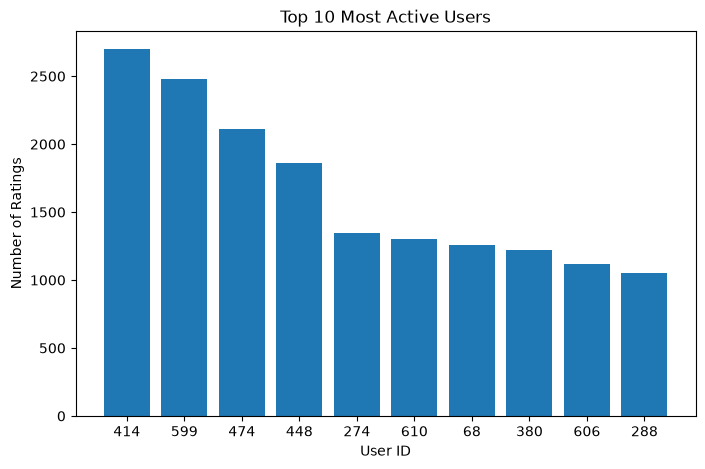

In [30]:
active_users = ratings["userId"].value_counts().head(10)

plt.figure(figsize=(8,5))

plt.bar(active_users.index.astype(str), active_users.values)

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")

plt.show()

# 🎬 Step 12: Highest Rated Movies

Display the movies with the highest average ratings.

In [31]:
movie_ratings = df.groupby("title")["rating"].mean().sort_values(ascending=False)

movie_ratings.head(10)

title
Karlson Returns (1970)                                                         5.0
Zeitgeist: Moving Forward (2011)                                               5.0
Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)    5.0
Dragons: Gift of the Night Fury (2011)                                         5.0
12 Angry Men (1997)                                                            5.0
Justice League: Doom (2012)                                                    5.0
Junior and Karlson (1968)                                                      5.0
Jump In! (2007)                                                                5.0
Human Condition III, The (Ningen no joken III) (1961)                          5.0
Louis Theroux: Law & Disorder (2008)                                           5.0
Name: rating, dtype: float64

C:\Users\Sachin Sharma\AppData\Local\Temp\ipykernel_14936\2234443245.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


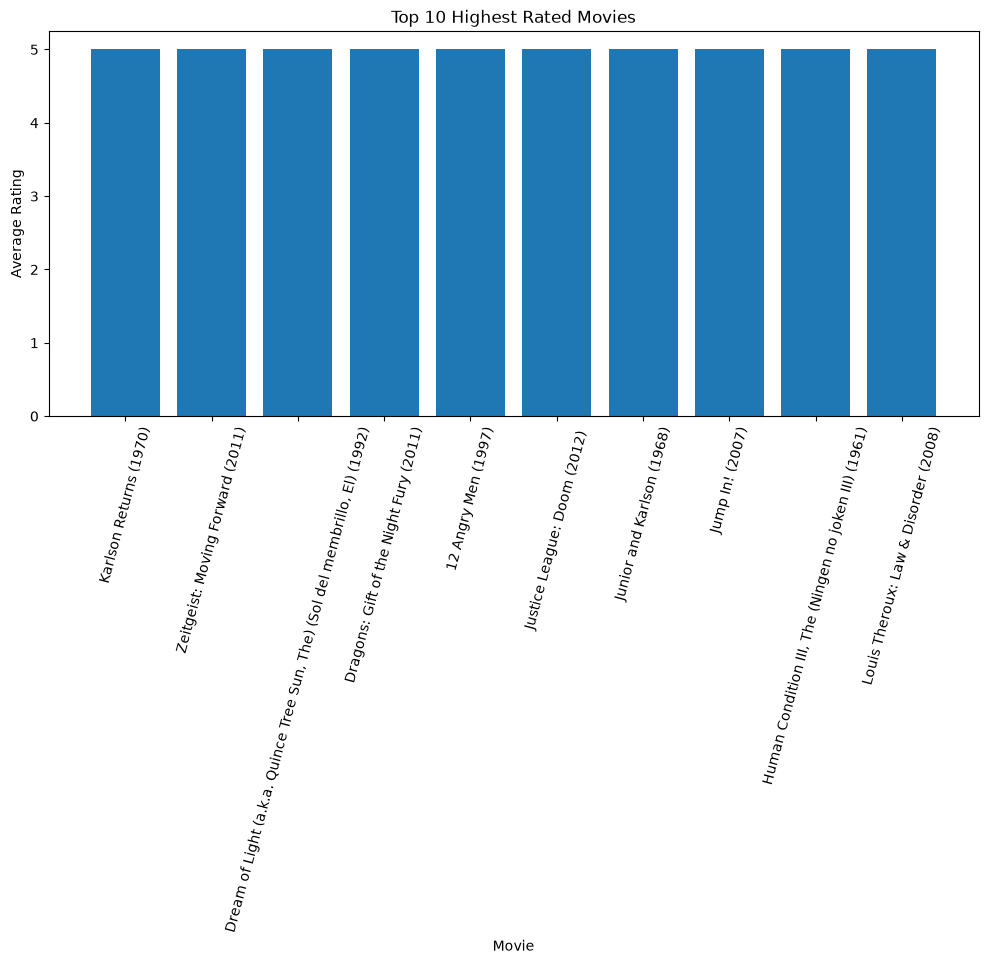

In [32]:
top10 = movie_ratings.head(10)

plt.figure(figsize=(12,5))

plt.bar(top10.index, top10.values)

plt.xticks(rotation=75)

plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Movie")
plt.ylabel("Average Rating")

plt.tight_layout()

plt.show()

# 💼 Step 13: Business Recommendations

### Recommendations

- Deliver personalized movie recommendations based on user preferences.
- Recommend trending and highly rated movies to new users.
- Continuously update recommendations as users provide new ratings.
- Increase user engagement by suggesting similar content.
- Improve customer satisfaction through personalized experiences.

# 🎯 Conclusion

This project successfully developed an AI-Based Recommendation System using collaborative filtering concepts and cosine similarity.

### Workflow Completed

- Data Collection
- Data Exploration
- Data Visualization
- Pattern Learning
- User-Movie Matrix Creation
- Recommendation Logic
- Recommendation Generation
- Evaluation Strategy
- Business Recommendations

The recommendation system demonstrates how AI can personalize user experiences and improve engagement by suggesting relevant content based on historical user preferences.

# 💾 Save Processed Dataset

Save the merged dataset for future recommendation analysis.

In [33]:
df.to_csv("movie_recommendation_data.csv", index=False)

print("✅ Recommendation dataset saved successfully!")

✅ Recommendation dataset saved successfully!
